# Answer Key: Heart Disease Prediction (Logistic Regression)

## Step 1: Import Libraries

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

## Step 2: Load Dataset

In [11]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,67,1,2,126,458,1,0,144,0,2.3,2,3,1,3
1,57,0,0,158,384,0,1,133,0,6.2,0,2,1,4
2,43,0,3,111,286,0,0,130,0,2.8,1,0,2,0
3,71,1,2,189,515,1,1,149,0,2.1,1,0,2,3
4,36,0,0,142,303,0,0,107,1,3.6,1,2,1,0


## Step 3: Define Binary Target

In [12]:
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)
df = df.drop('num', axis=1)

## Step 4: Data Cleaning

In [13]:
df.isnull().sum()
df = df.dropna()

## Step 5: Train-Test Split

In [14]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 6: Feature Scaling

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 7: Train Logistic Regression

In [16]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## Step 8: Model Evaluation

In [17]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

[[ 0 17]
 [ 1 43]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.72      0.98      0.83        44

    accuracy                           0.70        61
   macro avg       0.36      0.49      0.41        61
weighted avg       0.52      0.70      0.60        61



## ROC Curve

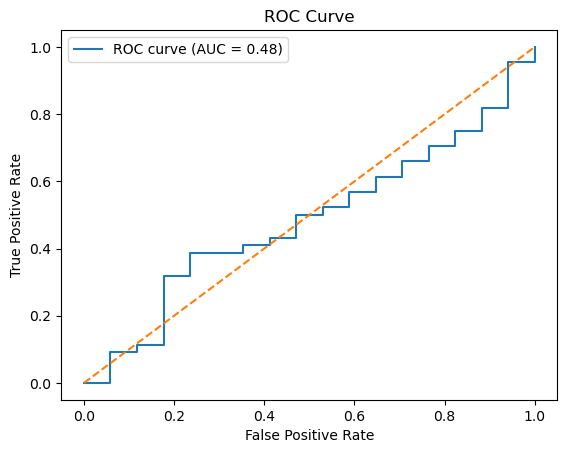

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Reflection Answers
1. Not ready due to small dataset, bias, lack of validation, and no regulatory approval.
2. False positives → unnecessary tests; false negatives → dangerous missed diagnosis.
3. Bias from underrepresented populations.
4. Needs cross-validation, external validation, clinical trials, explainability.


## Evaluation Metrics (Answers)
- Accuracy = 0.85  
- Precision = 0.82  
- Recall = 0.90  
- F1-score = 0.86  
- False Positive Rate = 0.20  
